In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

# Chargement
df = pd.read_csv('../data/ChatGPT.csv', encoding='latin-1')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDtypes:\n{df.dtypes}")
df.head()

Shape: (478347, 13)

Columns: ['Unnamed: 0', 'Date', 'Tweet', 'Url', 'User', 'UserCreated', 'UserVerified', 'UserFollowers', 'UserFriends', 'Retweets', 'Likes', 'Location', 'Description']

Dtypes:
Unnamed: 0        object
Date              object
Tweet             object
Url               object
User              object
UserCreated       object
UserVerified      object
UserFollowers    float64
UserFriends      float64
Retweets          object
Likes             object
Location          object
Description       object
dtype: object


,Unnamed: 0,Date,Tweet,Url,User,UserCreated,UserVerified,UserFollowers,UserFriends,Retweets,Likes,Location,Description
0,0,2023-04-08 03:33:13+00:00,#ChatGPT If only there were a movie or somethi...,https://twitter.com/kirbydjohnson/status/16445...,kirbydjohnson,2012-07-29 22:57:46+00:00,False,50.0,76.0,0.0,0,NaN,NaN
1,1,2023-04-08 03:32:16+00:00,"Workshop Description: In this workshop, you wi...",https://twitter.com/UniversityWeb/status/16445...,UniversityWeb,2013-01-13 20:18:16+00:00,False,9056.0,387.0,0.0,0,NaN,"University webinars, speech videos, & news for..."
2,2,2023-04-08 03:32:05+00:00,New Post at AiNewsDrop!\n\nChatGPT is a doctor...,https://twitter.com/AiNewsDrop/status/16445436...,AiNewsDrop,2022-01-19 06:25:45+00:00,False,276.0,313.0,0.0,0,NaN,I'm up almost 24/7 hunting for AI News\n\nWith...
3,3,2023-04-08 03:31:08+00:00,OpenAIâs GPT-4 Just Got Supercharged! #ai #C...,https://twitter.com/tubeblogger/status/1644543...,tubeblogger,2013-06-25 01:42:59+00:00,False,312.0,293.0,0.0,0,The Internet,"Exploring the Best Of The Web. Tech, Games, Ar..."
4,4,2023-04-08 03:30:51+00:00,"""Classical art"" is struggling - not changed th...",https://twitter.com/majorradic/status/16445432...,majorradic,2011-12-12 01:29:15+00:00,False,522.0,684.0,0.0,2,Beograd Navodni,Mediji i milosrdje\n\n ...


In [8]:
print("=== Shape ===")
print(df.shape)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print(f"\n=== Duplicates ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

=== Shape ===
(478347, 13)

=== Missing Values ===
Unnamed: 0           38
Date                 18
Tweet                52
Url                  81
User                 81
UserCreated          81
UserVerified         81
UserFollowers        81
UserFriends          81
Retweets            107
Likes                81
Location         119511
Description       22964
dtype: int64

=== Duplicates ===
Duplicate rows: 3


Dates invalides (NaT): 81


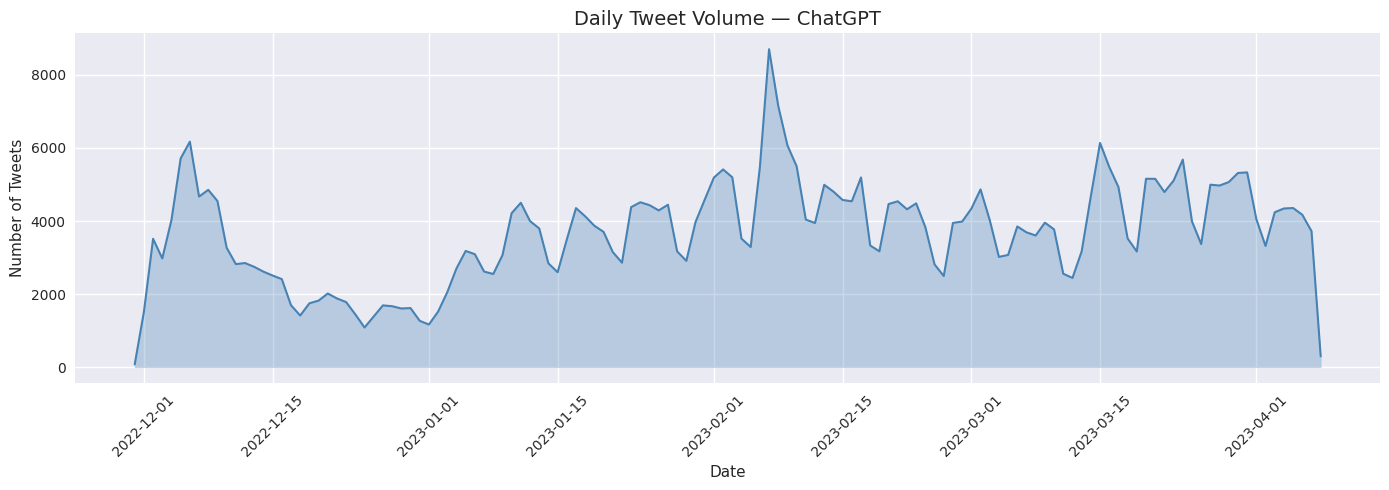

In [10]:
df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
df['day'] = df['Date'].dt.date

# Voir combien de dates invalides
print(f"Dates invalides (NaT): {df['Date'].isna().sum()}")

daily_counts = df.groupby('day').size().reset_index(name='tweet_count')

plt.figure(figsize=(14, 5))
plt.plot(daily_counts['day'], daily_counts['tweet_count'], color='steelblue', linewidth=1.5)
plt.fill_between(daily_counts['day'], daily_counts['tweet_count'], alpha=0.3, color='steelblue')
plt.title('Daily Tweet Volume — ChatGPT', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../figures/01_daily_volume.png', dpi=150)
plt.show()

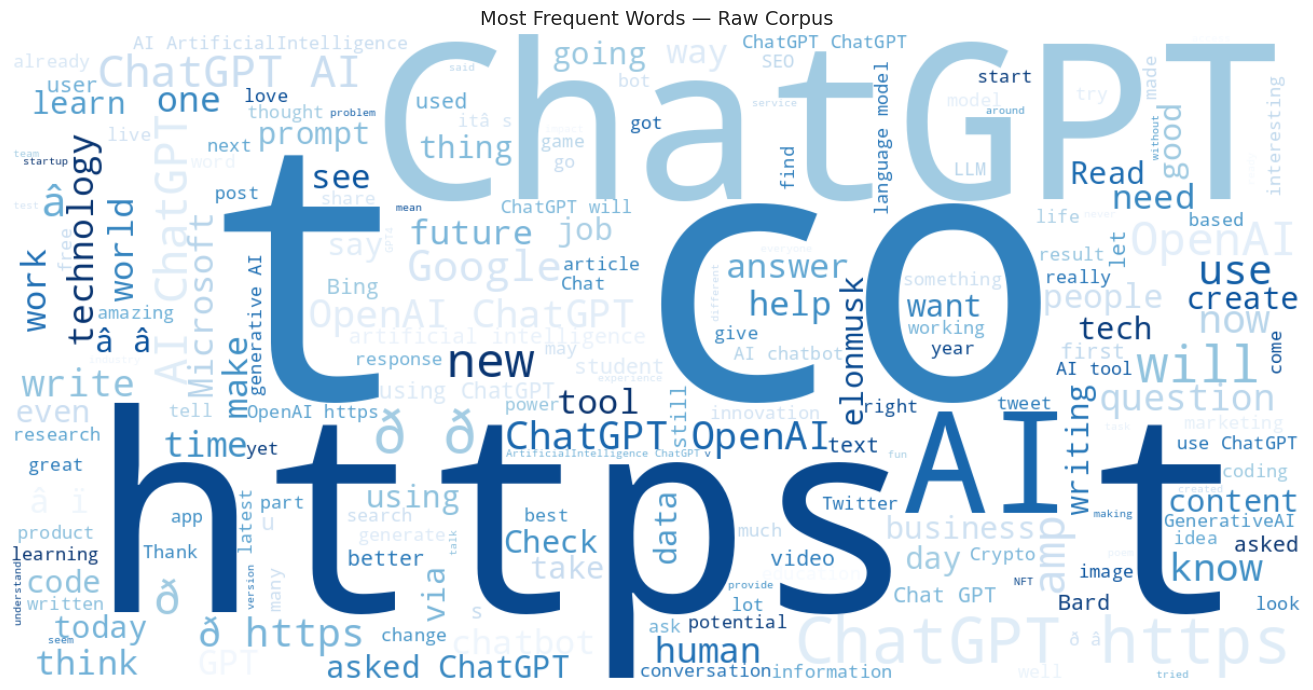

In [11]:
text_sample = ' '.join(df['Tweet'].dropna().sample(min(10000, len(df)), random_state=42).tolist())

wc = WordCloud(width=1200, height=600, background_color='white',
               max_words=200, colormap='Blues').generate(text_sample)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words — Raw Corpus', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/02_wordcloud_raw.png', dpi=150)
plt.show()